# Análise do Conjunto de Dados UEyes

## Bibliotecas

In [1]:
# bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# carregando conjunto de dados de fixações
df_fixations = pd.read_parquet(path='../data/core_fixations.parquet', engine='pyarrow')

df_fixations.sample(5)

,participant_id,block_id,MEDIA_NAME,TIME,FPOGX,FPOGY,FPOGD,FPOGV,SACCADE_MAG
7279,kh048,50,533daf.jpg,5.71729,0.62978,-0.07459,0.26318,1,170.29193
7431,kh048,50,8ed8ac.png,1.31396,0.17087,0.19115,0.24609,1,176.93324
8167,kh036,50,0ba80a.jpg,2.67676,0.28664,0.90429,0.34277,1,353.51538
3089,kh054,50,aa24d4.png,2.89160,0.66939,0.17445,0.39453,1,681.45831
8236,kh036,50,e9b913.png,5.17578,0.64217,0.67010,0.49316,1,301.52017


In [21]:
df_fixations.head(25)

,participant_id,block_id,MEDIA_NAME,TIME,FPOGX,FPOGY,FPOGD,FPOGV,SACCADE_MAG
0,kh025,50,aa24d4.png,0.31201,0.38835,0.06645,0.31201,1,0.00000
1,kh025,50,aa24d4.png,0.50928,0.48174,0.13206,0.18115,1,195.83249
2,kh025,50,aa24d4.png,0.98682,0.34861,0.03723,0.31299,1,279.79596
3,kh025,50,aa24d4.png,1.26440,0.21019,0.08163,0.26147,1,271.05453
4,kh025,50,aa24d4.png,1.60962,0.15678,0.12761,0.32861,1,116.44877
5,kh025,50,aa24d4.png,1.95435,0.17980,0.13824,0.32764,1,46.00232
6,kh025,50,aa24d4.png,2.21753,0.34132,0.10167,0.24658,1,313.20798
7,kh025,50,aa24d4.png,2.57886,0.53092,-0.04987,0.29565,1,406.92508
8,kh025,50,aa24d4.png,2.82520,0.63604,-0.01802,0.22974,1,205.41725
9,kh025,50,aa24d4.png,3.15381,0.57907,0.02496,0.31226,1,120.93223


In [3]:
df_fixations.describe()

,TIME,FPOGX,FPOGY,FPOGD,FPOGV,SACCADE_MAG
count,14816.000000,14816.000000,14816.000000,14816.000000,14816.0,14816.000000
mean,3.560396,0.446153,0.358880,0.314282,1.0,253.753667
std,2.115797,0.178780,0.268215,0.146056,0.0,229.688815
min,0.000000,-0.362010,-0.858140,0.000000,1.0,0.000000
25%,1.708980,0.339942,0.138995,0.229980,1.0,95.420712
50%,3.531980,0.448680,0.339320,0.279540,1.0,181.395750
75%,5.404940,0.544628,0.558800,0.376950,1.0,342.105457
max,7.080570,1.072650,2.207830,3.187010,1.0,2529.025390


Análise da distribuição de tempos de fixações.

In [18]:
# carregando conjunto de dados de informações das imagens
df_images = pd.read_parquet('../data/img_types_sizes.parquet', engine='pyarrow')
df_images.sample(5)

,Image Name,Category,Block,Train/Test,width,height
297,6cb6d4.jpg,mobile,8,Train,1080,1920
880,fc7118.jpg,mobile,24,Train,540,960
1876,ad1e05.png,desktop,53,Test,987,592
680,b3bf42.png,web,18,Train,1280,800
1564,dd47fa.jpg,mobile,43,Train,1080,1920


<Axes: title={'center': 'Distribuição da Frequência de Tempo'}, xlabel='Tempo em segundos', ylabel='Frequência'>

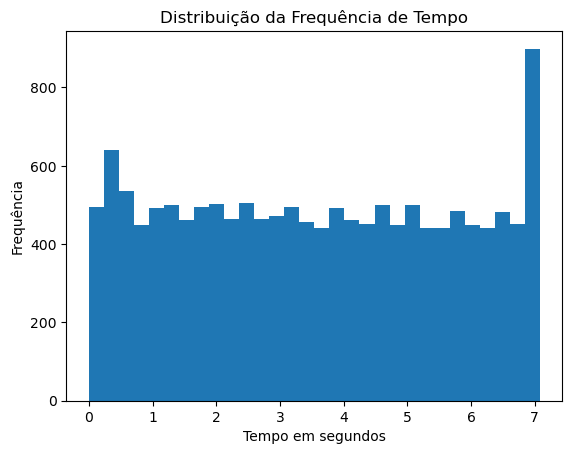

In [4]:
df_fixations['TIME'].plot(
    kind='hist',
    bins=30,
    title="Distribuição da Frequência de Tempo",
    xlabel='Tempo em segundos',
    ylabel='Frequência',
)

1º passo: processamento do número de fixações.

In [5]:
# máscaras para filtrar dataset
mask_early = df_fixations['TIME'] <= 3.5

mask_late = df_fixations['TIME'] > 3.5

In [7]:
# agrupamento para contagem de número de fixações ATÉ 3,5s
df_early = df_fixations[mask_early].groupby(
    ['participant_id', 'MEDIA_NAME']).size().reset_index(
        ['participant_id', 'MEDIA_NAME'], name='early_fixations')

df_late = df_fixations[mask_late].groupby(
    ['participant_id', 'MEDIA_NAME']).size().reset_index(
        ['participant_id', 'MEDIA_NAME'], name='late_fixations')

df_metrics = pd.merge(df_early, df_late, on=['participant_id', 'MEDIA_NAME'], how='left')

df_metrics

,participant_id,MEDIA_NAME,early_fixations,late_fixations
0,KH003,0950e7.png,8,11.0
1,KH003,0a0c95.jpg,11,10.0
2,KH003,0ba80a.jpg,9,9.0
3,KH003,15ac57.png,10,10.0
4,KH003,25426d.png,8,10.0
...,...,...,...,...
787,kh064,e9b913.png,8,8.0
788,kh064,efb9d2.jpg,10,9.0
789,kh064,f1e0ee.png,9,10.0
790,kh064,f3cfac.jpg,10,9.0


In [ ]:
# verificando linhas com valores nan
df_metrics[df_metrics.isna().any(axis=1)]

,participant_id,MEDIA_NAME,early_fixations,late_fixations
200,kh015,aa24d4.png,2,NaN
203,kh015,af9990.jpg,8,NaN


In [13]:
# substituindo por zero os valores nan (não visualizaram)
df_metrics['late_fixations'] = df_metrics['late_fixations'].fillna(0)

2º passo: processamento do tempo médio das fixações.

In [ ]:
df_early = df_fixations